<center>
<a href="https://www.vision.rwth-aachen.de/">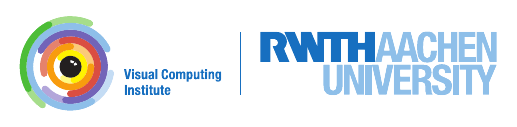</a>
</center>

# Computer Vision Exercises

**Assistants:**
<br>
George Lydakis &lt;lydakis@vision.rwth-aachen.de&gt;
<br>
Lucas Nunes &lt;nunes@vision.rwth-aachen.de&gt;

The assignments are **not mandatory and do not give bonus points for the exam**! The contents are relevant for the exam, though.

Make sure you fill in any place in *code cells* that says:
```python
# YOUR CODE HERE
raise NotImplementedError()
```

Make sure you fill in any place in *text cells* that says:
<br>

`YOUR ANSWER HERE`


### Submission:

⏰ Due date: 2026-05-18 23:59:00

**Important**:
Follow the instructions below when submitting your attempt.\
Submissions not following these instructions will not be graded.

1. Add the names and matriculation numbers of all team members below. Only **one team member should upload** the solutions.
2. **Use jupyter**. Other notebook-editing software (e.g. VSCode, pycharm) might corrupt the notebook files and could have issues with displaying matplotlib interactively.
3. **Do not remove, modify or duplicate** any given cells, except those in which you need to fill in your implementation. You can add new cells in order to present additional texts or plots.
4. **Restart the kernel and re-run the whole notebook** once before submission. After this step, the cell id should be incremental from top to bottom, and all plots should be displayed.
5. **Submit only the `.ipynb` files**, do not upload archives (zip, rar, tar, etc.), images or datasets.
6. **Do not change the filenames** of the `.ipynb` files.

Team members (names and matriculation numbers):
* 
* 
* 
* 

This exercise consists of three parts in three notebooks:
1. Edge Detection
2. Graph Cut Segmentation
3. Sliding Window Detection

# Edge Detection
In this part we will create a simple edge detector. 

Note: We will use `gauss`, `gaussdx`, `gauss_derivs` and `image_gradients_polar` from the first exercise.

In [1]:
# Some imports and convenience functions.

import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import cv2
import imageio


def gauss(x, sigma):
    return 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-(x**2) / (2 * sigma**2))


def gaussdx(x, sigma):
    return -1.0 / np.sqrt(2.0 * np.pi) / sigma**3 * x * np.exp(-(x**2) / 2.0 / sigma**2)


def gauss_derivs(image, sigma):
    kernel_radius = int(3.0 * sigma)
    x = np.arange(-kernel_radius, kernel_radius + 1)[np.newaxis]

    G = gauss(x, sigma)
    D = gaussdx(x, sigma)

    image_dx = convolve_with_two(image, D, G.T)
    image_dy = convolve_with_two(image, G, D.T)
    return image_dx, image_dy


def image_gradients_polar(image, sigma):
    grad_dx, grad_dy = gauss_derivs(image, sigma)
    magnitude = np.sqrt(grad_dx**2.0 + grad_dy**2.0)
    direction = np.arctan2(grad_dy, grad_dx)
    return magnitude, direction


def convolve_with_two(image, kernel1, kernel2):
    """Apply two filters, one after the other."""
    image = ndimage.convolve(image, kernel1)
    image = ndimage.convolve(image, kernel2)
    return image


def plot_multiple(
    images, titles, colormap="gray", max_columns=np.inf, imsize=4, share_axes=True
):
    """Plot multiple images as subplots on a grid."""
    assert len(images) == len(titles)
    n_images = len(images)
    n_cols = min(max_columns, n_images)
    n_rows = int(np.ceil(n_images / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * imsize, n_rows * imsize),
        squeeze=False,
        sharex=share_axes,
        sharey=share_axes,
    )

    axes = axes.flat
    # Hide subplots without content
    for ax in axes[n_images:]:
        ax.axis("off")

    if not isinstance(colormap, (list, tuple)):
        colormaps = [colormap] * n_images
    else:
        colormaps = colormap

    for ax, image, title, cmap in zip(axes, images, titles, colormaps):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)

    fig.tight_layout()

Write a function ``get_edges`` that returns a binary image ``edge`` from an input image where the color of each pixel $p$ is selected as follows (for a given threshold ``theta``):
\begin{eqnarray}
    \hat p &=&
    \begin{cases}
        1, &\text{ if }\left|\operatorname{grad}(\mathtt{img})\right|(p) \geq \theta\\
        0, &\text{ else}
    \end{cases}
\end{eqnarray}
Experiment with the function ``get_edges`` on the example images.
Try to get good edge images for different values of ``sigma``.
What difficulties do you observe when selecting ``sigma`` and ``theta``?

In [2]:
# POINTS: 1

def get_edges(image, sigma, theta):
    # YOUR CODE HERE
    magnitude, direction = image_gradients_polar(image,sigma)
    edge = (magnitude >= theta).astype(np.float32)
    return edge

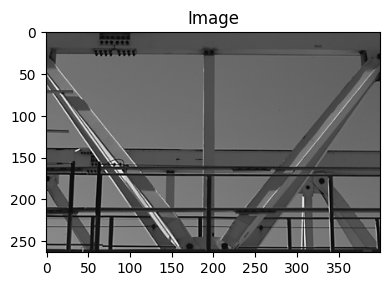

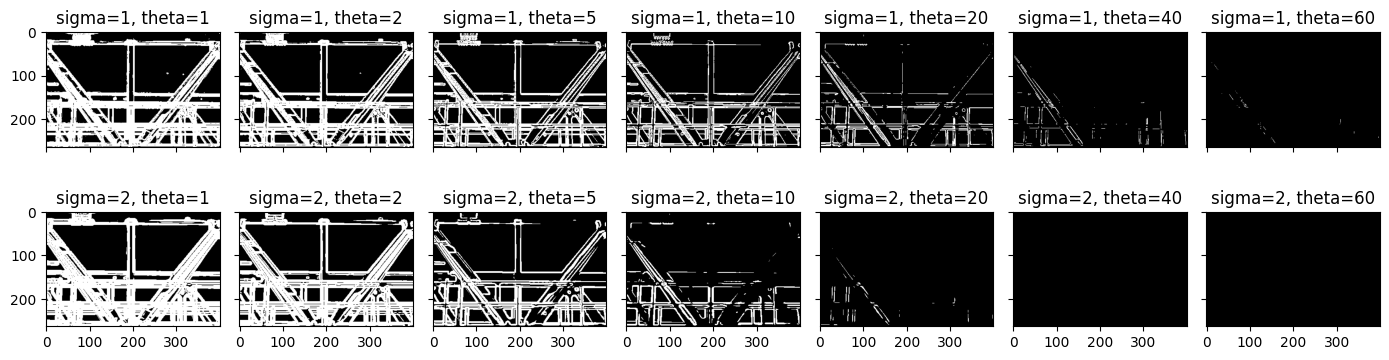

In [3]:
color_im = imageio.v2.imread("gantrycrane.png")
gray_im = cv2.cvtColor(color_im, cv2.COLOR_RGB2GRAY).astype(np.float32)
plot_multiple([gray_im], ["Image"])

sigmas = [1, 2]
thetas = [1, 2, 5, 10, 20, 40, 60]

images = []
titles = []
for sigma in sigmas:
    for theta in thetas:
        edges = get_edges(gray_im, sigma, theta)
        images.append(edges)
        titles.append(f"sigma={sigma}, theta={theta}")

plot_multiple(images, titles, max_columns=7, imsize=2)

Using the above function, returned edges are still several pixels wide.
In practice, this is often not desired.
Create a function ``get_edges_with_nms`` that extends ``get_edges`` by using `nms_for_edges` to suppress non-maximum points along the gradient direction.

We only expect a simplified implementation which does not interpolate between neighboring pixel values in order to look up the real magnitude along the gradient direction.
Such an interpolation would be crucial to obtain the necessary robustness for an actual implementation.
We leave it out for better readability, since the interpolation involves some extra effort in order to deal with all special cases (e.g. exactly horizontal or vertical gradients).
If you feel motivated, you can try to add this step to make the function more robust.

In [4]:
# POINTS: 4

def nms_for_edges(grad_mag, grad_dir):
    result = np.zeros_like(grad_mag)

    # Pre-define pixel index offset along different orientation
    offsets_x = [-1, -1, 0, 1, 1, 1, 0, -1, -1]
    offsets_y = [0, -1, -1, -1, 0, 1, 1, 1, 0]
    height, width = grad_mag.shape
    for y in range(1, height - 1):
        for x in range(1, width - 1):
            # YOUR CODE HERE
            angle = grad_dir[y,x]

            # convert angle to sector index [0...7]
            direction = int(np.round(angle/(np.pi/4)))%8
            dx = offsets_x[direction]
            dy = offsets_y[direction]

            current = grad_mag[y, x]
            neighbour1 = grad_mag[y+dy, x+dx]
            neighbour2 = grad_mag[y-dy, x-dx]

            if current >= neighbour1 and current >= neighbour2:
                       result[y, x] = current

    return result

Another problem is that suitable values for ``theta`` may vary substantially between images.
Extend the function ``get_edges_with_nms`` such that the threshold $\theta \in [0,1]$ is defined relative to the maximal gradient magnitude value in the image.

In [5]:
# POINTS: 1

def get_edges_with_nms(image, sigma, theta):
    grad_mag, grad_dir = image_gradients_polar(image,sigma)

    suppressed = nms_for_edges(grad_mag, grad_dir)

    edge = (suppressed >= theta).astype(np.float32)
    
    return edge

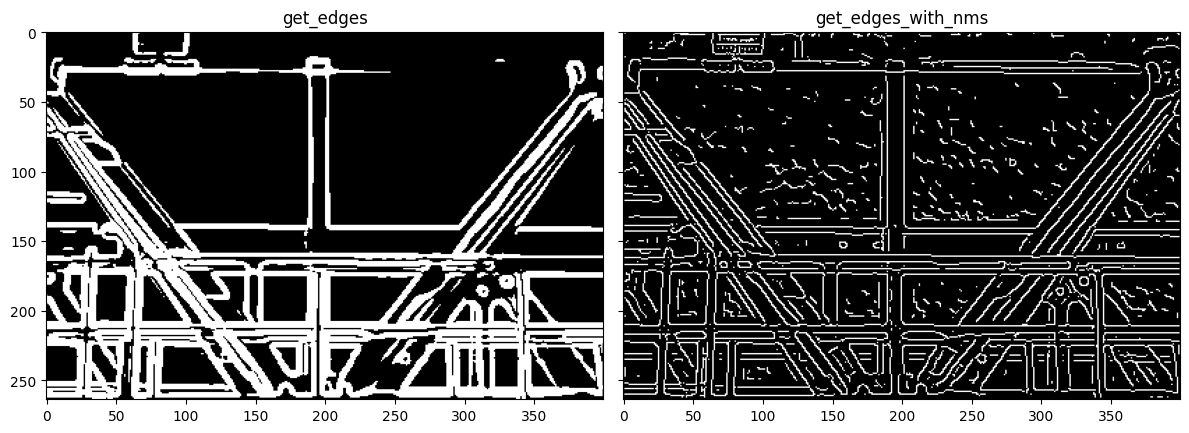

In [6]:
edges1 = get_edges(gray_im, sigma=2, theta=5)
edges2 = get_edges_with_nms(
    gray_im, sigma=2, theta=0.17
)  # 0.17 corresponds to an absolute threshold of 5

plot_multiple([edges1, edges2], ["get_edges", "get_edges_with_nms"], imsize=6)

The function ``get_edges`` you implemented is a simplified version of the Canny edge detection pipeline.
The main step that is still missing is the edge following with hysteresis thresholding.
The idea here is that instead of applying a single threshold over the entire image, the edge detector works with two different thresholds ``theta_high`` and ``theta_low``.
It starts with an edge pixel with a value above ``theta_high`` and then follows the contour in the direction orthogonal to the gradient until the pixel value falls below ``theta_low``.
Each pixel visited along the way is labeled as an edge.
The procedure is repeated until no further pixel above ``theta_high`` remains.

Try writing a function ``my_canny`` that implements this procedure.
Don't worry about efficiency for the moment.
The following hints may help you:
- You can create a boolean array ``visited`` for already visited and yet-to-visit image pixels. Since we are not interested in pixels below the low threshold you can mark them as visited. In another boolean array you can flag the pixels that serve as starting points for line following.
- You can also avoid having to deal with special cases along the image borders by creating a 1-pixel boundary where the ``visited`` flag is set to ``true``.
- The actual edge following part is most easily implemented as a recursive procedure. In most cases, you will have the option to choose between several possible continuation points. Again, the easiest way is to try all of them in sequence (or even all 8 neighbors) and let the recursive procedure (together with the ``visited`` flags) do the rest.

In [7]:
# POINTS: 5

def my_canny(image, sigma, theta_low, theta_high):
    # Compute gradient, apply non-maximum suppression
    # YOUR CODE HERE
    grad_mag, grad_dir = image_gradients_polar(image, sigma)
    grad_mag = nms_for_edges(grad_mag, grad_dir)

    # Compute absolute threshold relative to max value
    max_val = np.max(grad_mag)
    theta_low_abs = theta_low * max_val
    theta_high_abs = theta_high * max_val

    # Initialize flags
    # Declare all pixels below the low threshold as visited
    # so edges are not followed there
    visited = grad_mag < theta_low_abs

    # Mark boundary pixels as visited
    visited[:, 0] = 1
    visited[:, -1] = 1
    visited[0, :] = 1
    visited[-1, :] = 1

    # Output image
    image_out = np.zeros_like(image)

    def follow_edge(x, y):
        visited[y, x] = True
        image_out[y, x] = 255

        # Pre-define pixel index offset along different orientation
        offsets_x = [-1, -1, 0, 1, 1, 1, 0, -1]
        offsets_y = [0, -1, -1, -1, 0, 1, 1, 1]

        for ox, oy in zip(offsets_x, offsets_y):
            # Note: `visited` is already True for points
            # below the low threshold.

            # YOUR CODE HERE
            nx = x + ox
            ny = y + oy

            if not visited[ny, nx]:
                follow_edge(nx, ny)

    is_high = grad_mag >= theta_high_abs
    # Main loop
    for x in range(image.shape[1]):
        for y in range(image.shape[0]):
            # YOUR CODE HERE
            if is_high[y, x] and not visited[y,x]:
                follow_edge(x, y)

    return image_out

OpenCV provides a built-in function that implements the Canny edge detector.
Try ``cv2.Canny`` on the provided example images and compare the results to those of your implementation.
Note: the implementation of ``cv2.Canny`` does not include blurring the image as we did.
So apply ``cv2.GaussianBlur`` on the image, before passing it to ``cv2.Canny``.

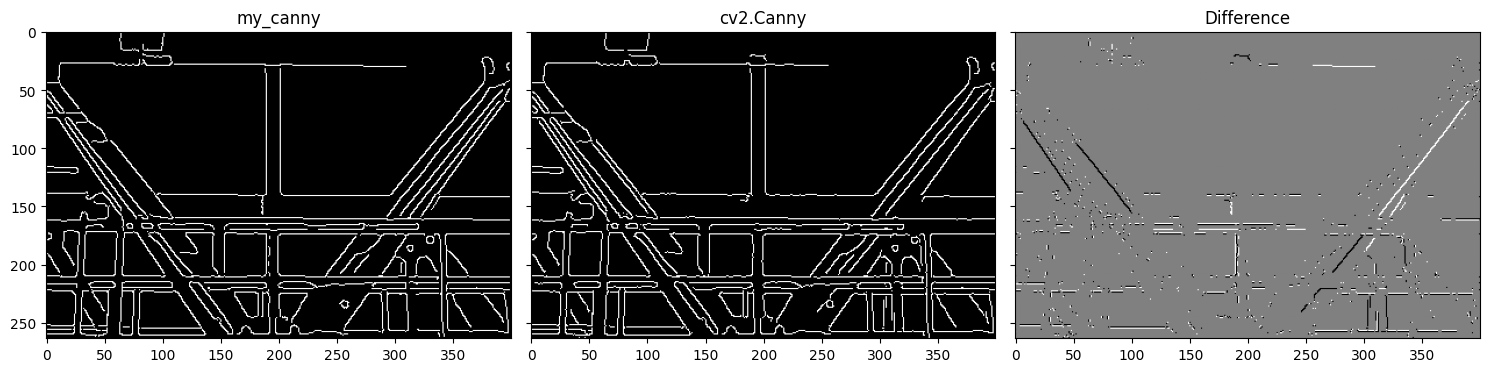

In [8]:
edge_canny = my_canny(gray_im, sigma=2, theta_low=0.1, theta_high=0.3)

blurred_cv = cv2.GaussianBlur(gray_im, ksize=(7, 7), sigmaX=2)
edge_canny_cv = cv2.Canny(blurred_cv.astype(np.uint8), 39, 72, L2gradient=True).astype(
    np.float32
)

plot_multiple(
    [edge_canny, edge_canny_cv, edge_canny - edge_canny_cv],
    ["my_canny", "cv2.Canny", "Difference"],
    imsize=5,
)